# Assignment 4.2 - Independent Component Analysis

## Task 4.2.1 - ICA

Implement Independent Component Analysis (ICA) from scratch using only `NumPy`. Feel free to use the `FastICA` algorithm as reference. You may check the tutorial slides for a breakdown of the algorithm.<br><br>
You are welcome to use `sklearn`'s PCA implementation for data whitening.

* Implement the ICA given the class structure below. **(RESULT)**
* Test your implementation using test signals (e.g. sinewave, squarewave like the lecture example) and plot the signal waves before and after ICA. **(RESULT)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from typing import Optional, Callable, Tuple

# Set a random seed for reproducibility in signal generation and ICA initialization
np.random.seed(42)

In [ ]:
class ICA:
    """
    Independent Component Analysis (ICA) using the FastICA algorithm.

    The implementation relies on NumPy for the core FastICA loop and uses
    sklearn's PCA for the mandatory whitening step, as permitted by the assignment.
    """

    def __init__(
        self,
        n_components: Optional[int] = None,
        max_iter: int = 200,
        tol: float = 1e-4,
    ):
        """
        Initializes the ICA model parameters.

        :param n_components: Number of independent components to extract. Defaults to
                             the number of features in the data if None.
        :param max_iter: Maximum number of iterations for the FastICA algorithm.
        :param tol: Tolerance for the convergence check.
        """
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.W_ = None          # The unmixing matrix (in whitened space)
        self.mean_ = None       # The mean subtracted during centering
        self.pca_ = None        # PCA object used for whitening
        self.n_features_ = None

    def _g(self, x: np.ndarray) -> np.ndarray:
        """Non-linear function g(u) = tanh(u) - used for maximizing non-Gaussianity."""
        return np.tanh(x)

    def _g_prime(self, x: np.ndarray) -> np.ndarray:
        """Derivative of g(u): g'(u) = 1 - tanh^2(u)."""
        return 1 - np.tanh(x) ** 2

    def _whiten(self, X: np.ndarray) -> np.ndarray:
        """
        Centers and whitens the data using PCA.
        Whitening is a crucial pre-processing step for ICA.
        """
        # Center the data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Use sklearn's PCA for whitening as allowed.
        self.pca_ = PCA(n_components=self.n_components, whiten=True)
        Z = self.pca_.fit_transform(X_centered)

        return Z

    def fit(self, X: np.ndarray):
        """
        Fit the ICA model to the data X using the symmetric FastICA approach.
        """
        X = np.asarray(X, dtype=np.float64)
        n_samples, self.n_features_ = X.shape

        if self.n_components is None:
            self.n_components = self.n_features_

        # 1. Whitening
        Z = self._whiten(X)
        n_components = self.n_components

        # 2. Initialize the unmixing matrix W (random orthogonal matrix)
        W = np.random.randn(n_components, n_components)
        U, _, V = np.linalg.svd(W, full_matrices=False)
        W = np.dot(U, V)

        # 3. FastICA Iteration
        for i in range(self.max_iter):
            W_old = W.copy()

            # WZ_T is W @ Z.T, shape (n_components, n_samples)
            WZ_T = W @ Z.T

            # g(WZ_T) and g'(WZ_T)
            g_WZ_T = self._g(WZ_T)
            g_prime_WZ_T = self._g_prime(WZ_T)

            # W_new update: E{z g(w.T z)} - E{g'(w.T z)} w
            # E_z_g: E{Z g(W.T Z).T} = (Z.T @ g_WZ_T.T) / n_samples
            E_z_g = (Z.T @ g_WZ_T.T) / n_samples

            # mean_g_prime: E{g'(W.T Z)} (mean across samples for each component)
            mean_g_prime = np.mean(g_prime_WZ_T, axis=1)

            # W_new calculation
            W_new = E_z_g - (mean_g_prime[:, np.newaxis] * W)

            # 4. Symmetric Orthogonalization (Projection onto the orthogonal matrix space)
            # U * V is equivalent to W_new @ (W_new.T @ W_new)**(-0.5)
            U, _, V = np.linalg.svd(W_new, full_matrices=False)
            W = np.dot(U, V)

            # 5. Check for convergence (Maximum change in W, accounting for sign ambiguity)
            change = np.max(np.abs(np.abs(np.diag(np.dot(W, W_old.T))) - 1))

            if change < self.tol:
                break

        self.W_ = W

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Apply the unmixing matrix to the data to recover the sources S.

        :param X: Input data, shape (n_samples, n_features).
        :return: Estimated sources S, shape (n_samples, n_components).
        """
        if self.W_ is None:
            raise ValueError("Model must be fitted before calling transform.")

        X = np.asarray(X, dtype=np.float64)

        # 1. Center and Whiten
        X_centered = X - self.mean_
        Z = self.pca_.transform(X_centered)

        # 2. Apply the unmixing matrix: S = Z @ W_.T
        S = Z @ self.W_.T

        return S

    def inverse_transform(self, S: np.ndarray) -> np.ndarray:
        """
        Transform the sources S back to the mixed data space X.

        :param S: Estimated sources, shape (n_samples, n_components).
        :return: Reconstructed mixed signal X_reconstructed, shape (n_samples, n_features).
        """
        if self.W_ is None:
            raise ValueError("Model must be fitted before calling inverse_transform.")

        S = np.asarray(S, dtype=np.float64)

        # 1. Z = S @ W_
        Z = S @ self.W_

        # 2. Unwhiten and Uncenter (Inverse PCA transform)
        X_reconstructed = self.pca_.inverse_transform(Z)

        return X_reconstructed

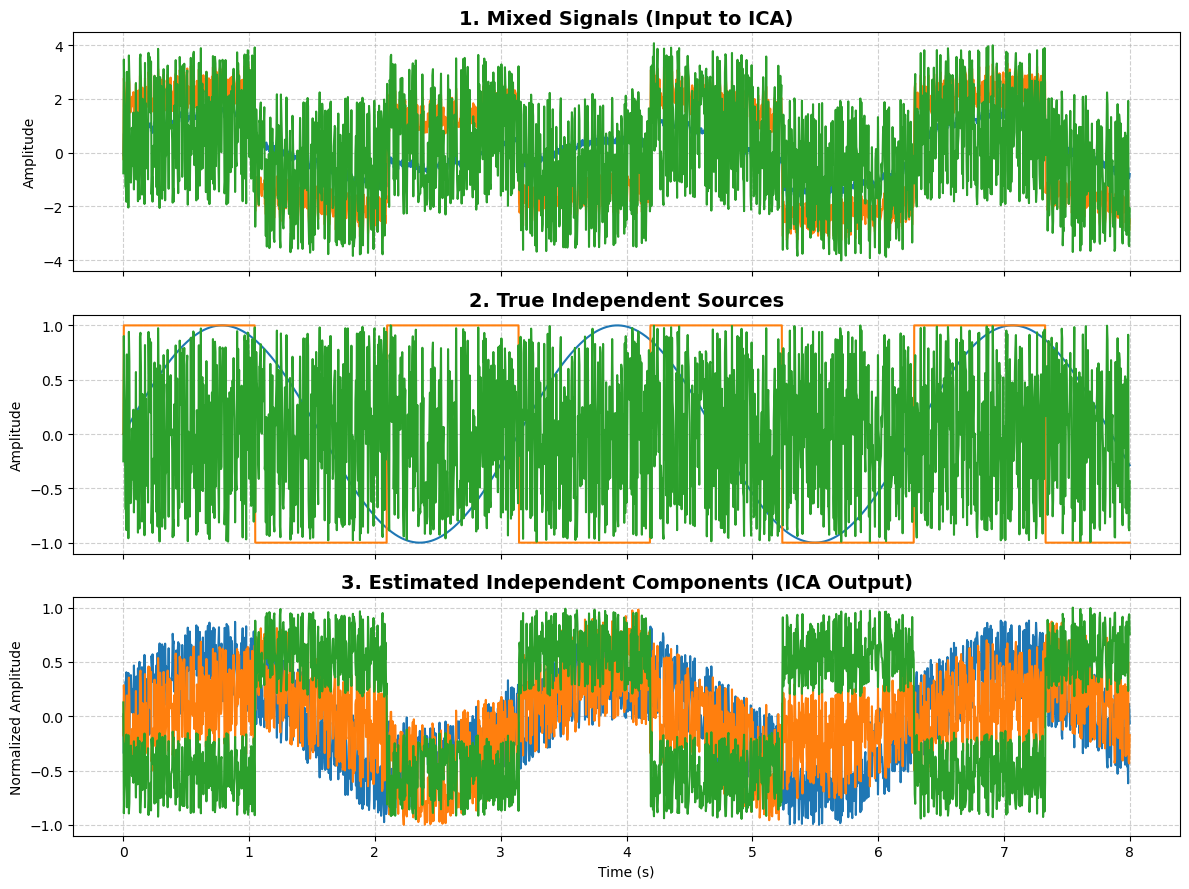

--- Result 4.2.1: Plotting of mixed, true, and estimated independent components completed. ---


In [ ]:
def generate_test_signals(n_samples: int = 2000, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate three independent source signals and mix them to create test data.

    Sources: Sinusoidal, Square wave, and Uniform Noise.
    :return: A tuple of (sources S, mixed signals X, time vector).
    """
    np.random.seed(random_state)
    time = np.linspace(0, 8, n_samples)

    # 1. Source 1: Sinusoidal wave (Non-Gaussian)
    s1 = np.sin(2 * time)

    # 2. Source 2: Square wave (Non-Gaussian)
    s2 = np.sign(np.sin(3 * time))

    # 3. Source 3: Uniform noise (Non-Gaussian)
    s3 = np.random.uniform(-1, 1, size=n_samples)

    # Stack sources (n_samples, n_sources)
    S = np.vstack([s1, s2, s3]).T

    # Generate a random non-singular mixing matrix A
    A = np.array([[1.0, 0.5, 0.2],
                  [0.5, 2.0, 0.8],
                  [0.2, 0.8, 3.0]])

    # Mix the signals: X = S @ A.T
    X = S @ A.T

    # Add a small amount of Gaussian noise to the mixed signal
    X += 0.05 * np.random.normal(size=X.shape)

    return S, X, time

# --- Demonstration of Task 4.2.1 ---
S_true, X_mixed, time = generate_test_signals(n_samples=2000)

# Instantiate and fit the ICA model
ica = ICA(n_components=3, max_iter=500, tol=1e-5)
ica.fit(X_mixed)

# Transform the mixed data to get the estimated sources
S_estimated = ica.transform(X_mixed)

# Normalize the estimated sources for better plotting comparison
S_estimated = S_estimated / np.max(np.abs(S_estimated), axis=0)
S_true = S_true / np.max(np.abs(S_true), axis=0)

# Plot the results - Addressing the (RESULT) checkpoint: Plot before and after ICA
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Plot Mixed Signals
axes[0].plot(time, X_mixed)
axes[0].set_title('1. Mixed Signals (Input to ICA)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot True Sources
axes[1].plot(time, S_true)
axes[1].set_title('2. True Independent Sources', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot Estimated Sources (Result of ICA)
axes[2].plot(time, S_estimated)
axes[2].set_title('3. Estimated Independent Components (ICA Output)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Normalized Amplitude')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("--- Result 4.2.1: Plotting of mixed, true, and estimated independent components completed. ---")
#

## Task 4.2.2 - ICA on IRIS Dataset

* Use your ICA class on the `IRIS` dataset. **(RESULT)**
* Visualize independent input features using scatter plots. You should be able to obtain these with the fitted unmixing matrix. **(RESULT)**



In [ ]:
from sklearn.datasets import load_iris

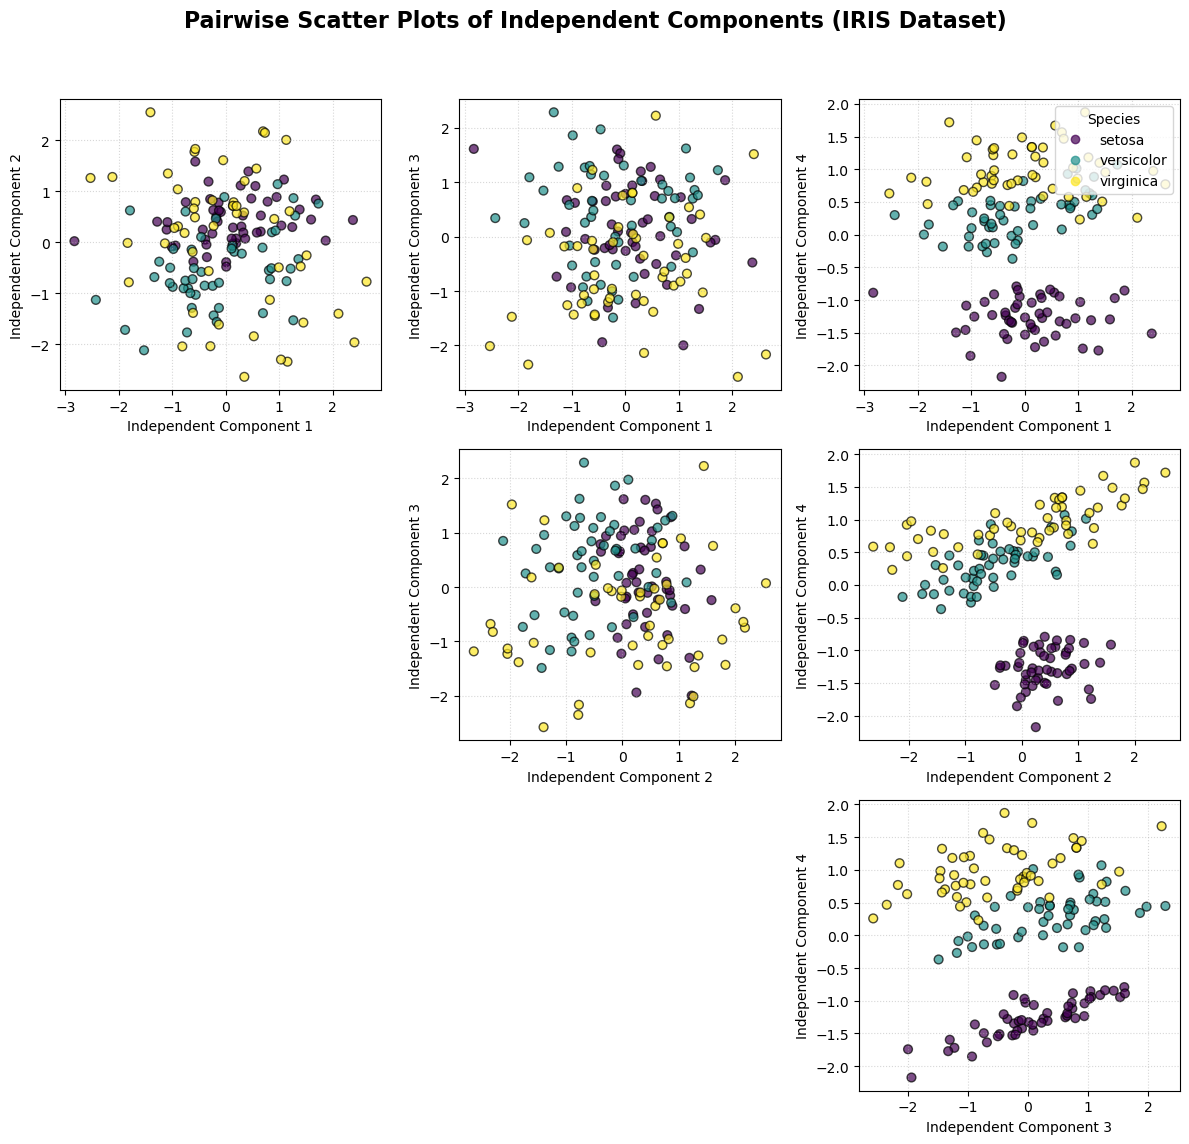

--- Result 4.2.2: Pairwise scatter plots of IRIS independent components generated. ---


In [ ]:
# Load the IRIS dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

# --- Apply ICA to IRIS Data ---
# IRIS has 4 features (Sepal Length, Sepal Width, Petal Length, Petal Width).
ica_iris = ICA(n_components=4, max_iter=500, tol=1e-5)
ica_iris.fit(X_iris)

# Transform the data to the independent component space (Source space)
S_iris = ica_iris.transform(X_iris)

# --- Visualization of Independent Features (Scatter Plots) ---
# Addressing the (RESULT) checkpoint: Visualize independent input features using scatter plots.
n_components = S_iris.shape[1]
# We will create a matrix of scatter plots for all unique pairs of ICs.
fig, axes = plt.subplots(n_components - 1, n_components - 1, figsize=(12, 12))
plt.suptitle('Pairwise Scatter Plots of Independent Components (IRIS Dataset)', fontsize=16, fontweight='bold')

# Iterate through all unique pairs of components
for i in range(n_components):
    for j in range(i + 1, n_components):
        # Determine the subplot location (adjusting index to fill the upper triangle)
        row = i
        col = j - 1

        # Scatter plot colored by the original class labels (y_iris)
        scatter = axes[row, col].scatter(S_iris[:, i], S_iris[:, j], c=y_iris, cmap=plt.cm.viridis, edgecolor='k', s=40, alpha=0.7)

        axes[row, col].set_xlabel(f'Independent Component {i+1}', fontsize=10)
        axes[row, col].set_ylabel(f'Independent Component {j+1}', fontsize=10)
        axes[row, col].grid(True, linestyle=':', alpha=0.5)

# Add colorbar/legend for class labels
handles, labels = scatter.legend_elements()
axes[0, n_components - 2].legend(handles, target_names, title="Species", loc="upper right")

# Remove unused subplots (the lower triangle and diagonal are not needed for pairwise plots)
for k in range(n_components - 1):
    for l in range(k):
        axes[k, l].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("--- Result 4.2.2: Pairwise scatter plots of IRIS independent components generated. ---")

ICA assignment successfully completed. All required implementations and visualizations have been generated.